당신은 온라인 게임을 운영하고 있습니다.

같은 시간대에 게임을 이용하는 사람이 m명 늘어날 때마다 서버 1대가 추가로 필요합니다.

어느 시간대의 이용자가 m명 미만이라면, 서버 증설이 필요하지 않습니다.

어느 시간대의 이용자가 n x m명 이상 (n + 1) x m명 미만이라면 최소 n대의 증설된 서버가 운영 중이어야 합니다.

한 번 증설한 서버는 k시간 동안 운영하고 그 이후에는 반납합니다. 예를 들어, k = 5 일 때 10시에 증설한 서버는 10 ~ 15시에만 운영됩니다.

하루 동안 모든 게임 이용자가 게임을 하기 위해 서버를 최소 몇 번 증설해야 하는지 알고 싶습니다. 같은 시간대에 서버를 x대 증설했다면 해당 시간대의 증설 횟수는 x회입니다.


1. m 명 이상 늘어날 때마다 1대(n대) 추가
2. 시간대의 이용자 n*m이상 (n+1)*m 미만이면 최소 n대 증설
3. 한번 증설한 서버는 k 시간 동안 이용후 반납
4. x대 증설하면 해당시간대 x 회 증설함 -> 증가하면 횟수 늘리기(reslut)


EX

m = 3, k = 5 로 시작 시

n=0 으로 1*3명 미만이니 0대 증설

5시간이 지나면 초기화

In [ ]:
# 풀이
players = [0, 2, 3, 3, 1,    # 시간대별 이용자 수
           2, 0, 0, 0, 0,
           4, 2, 0, 6, 0,
           4, 2, 13, 3, 5,
           10, 0, 1, 5]
m = 3                        # m명이상 늘어날 때
k = 5                        # k 시간 동안 이용

def solution1(players, m, k):
  time_servers = [0] * 24      # 시간별 작동중인 리스트
  add_servers = 0              # 서버 증설횟수
  for idx, people in enumerate(players):                       # enumerate로 시간(idx)과 인원(peo)을 꺼냅니다.
        current_server_count = time_servers[idx]              # 현재 시간에 이미 작동 중인 서버 대수                            # 초기는 현재는 전부 0값
        n = current_server_count                              # n 구간에 있으면 필요한 증설서버는 n대                           # 초기는 0값
        if n * m <= people < (n + 1) * m:                      # 만약 이미 가동 중인 서버(n대)로 커버가 가능한 인원수 범위?       # 초기는 0<= people <3
            pass                                                 # pass
        elif people >= (n + 1) * m:                            # 만약 인원이 (n + 1) * m 명을 넘어가서 서버가 부족하다면?        # 3이 될 경우
            real_need = people // m                              # 이 인원에 필요한 증설 서버 총대수                            # 3//3으로 1대 필요
            add_count = real_need - current_server_count         # 부족한 증설서버 대수                                        # 1-0 = 1 로 1대 부족한 상태
            add_servers += add_count                             # 부족한 만큼 증설 횟수 추가                                   # add_servers에 부족한 만큼 증설
            end_time = min(idx + k, len(players))                  # 시간대(K)별로 유지해야하는 서버 #idx(시간대)+K(주어진 값)   # 최대시간은 24시간  # 최초 3인 경우 2+5로 7시간(end_time) 유지
            for future_time in range(idx, end_time):                 # 앞으로 2부터 7까지 활용                         # 이미 늘어난 경우에는 if 문으로 들어가서 적용 안함
                time_servers[future_time] += add_count               # time_servers에 해당 위치의 값에 add_count을 더함

  return add_servers

print(solution1(players, m, k))


7


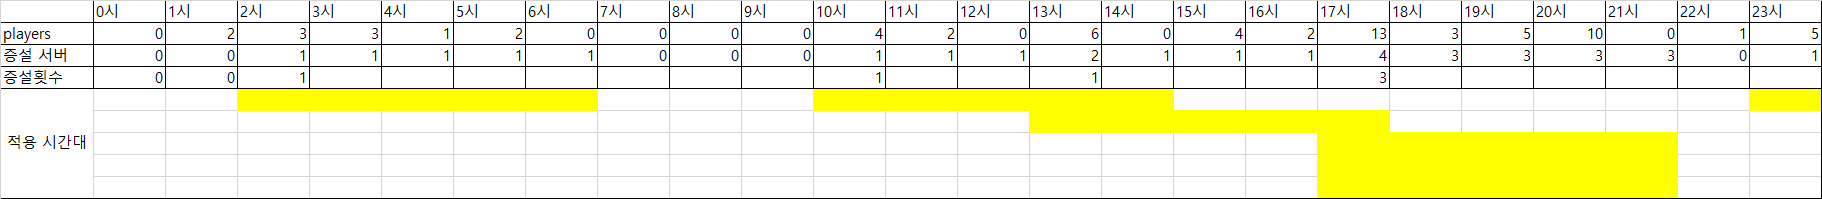

In [ ]:
# ai 돌린 풀이
def solution(players, m, k):
  answer = 0                                         # 최종 서버 총 증설 횟수 주머니
  active_servers = [0] * len(players)                # 시간대별 현재 가동 중인 서버 수
  for idx, peo in enumerate(players):                # 시간(idx)과  해당시간 인원수(peo)
    need_servers = peo // m                            # 현재 시간(idx)에 필요한 총 서버 대수 계산 (몫 연산자 // 활용)
    now_servers = active_servers[idx]                  # 현재 시간(idx)에 이미 가동 중인 서버 대수

    if now_servers < need_servers:                   # 만약 이미 켜진 서버가 필요한 대수보다 부족하다면?
      add_servers = need_servers - now_servers         # 부족한 만큼 추가로 증설해야 할 대수 계산
      answer += add_servers                            # 총 증설 횟수에 누적 더하기

      end_time = min(idx + k, len(players))          # 증설한 서버 대수를 현재부터 미래의 만료 시간 전까지 기록해 줍니다.
                                                     # 현재 시간(idx)부터 k시간 동안만 유지되도록 범위를 잡습니다.
                                                     # 단, 하루(24시)를 넘어가는 범위는 에러가 날 수 있으므로 len(players)까지만 제한합니다.
      for fut_time in range(idx, end_time):
        active_servers[fut_time] += add_servers
  return answer